In [ ]:
import numpy as np
import matplotlib.pyplot as plt
import datetime
from matplotlib import rc

def run_hardmax_dyn_V(z0, A, R, RV, num_steps=30, tails=True):
    d, n = z0.shape
    W = np.zeros((d, n))
    
    # Set up plotting
    saving_iter = [0, num_steps]
    fig, axs = plt.subplots(1, np.size(saving_iter), figsize=(4, 4))

    # Generate different shades of blue
    color = np.array([80, 132, 240]) / 255 

    ## Run the HARDMAX dynamics ##
    z = np.zeros((d, n, num_steps+1))
    z[:, :, 0] = z0
    f = z0.copy()
    
    for iter in range(1,num_steps+1):
        # Get dynamics
        for i in range(n):
            IP = np.dot(f[:, i].T, np.dot(A,f))
            Pij = np.zeros(n)
            ind = IP == np.max(IP)
            Pij[ind] = 1. / np.sum(ind)
            W[:, i] = RV @ np.sum(Pij * f, axis=1)
        f = R @ f + W
        z[:, :, iter] = f

    # Get the leader values at each layer
    leaders = []
    for iter in range(num_steps + 1):
        leader_particles = []
        for i in range(n):
            y = np.dot(z[:, i, iter], np.dot(A,z[:, :, iter]))
            ind = y == np.max(y)
            if i == np.where(ind)[0][0]:
                leader_particles.append(np.where(ind)[0][0])
        leaders.append(leader_particles)

    x_min, x_max = z[0, :, :].min(), z[0, :, :].max()
    y_min, y_max = z[1, :, :].min(), z[1, :, :].max()

    margin = 0.1
    x_range = x_max - x_min
    x_min -= margin * x_range
    x_max += margin * x_range
    y_range = y_max - y_min
    y_min -= margin * y_range
    y_max += margin * y_range

    rc("text", usetex = True)
    font = {'size'   : 10}
    rc('font', **font)
    # Set fixed axis properties for all subplots
    for ax in axs.flat:
        label_size = 10
        plt.rcParams['xtick.labelsize'] = label_size
        plt.rcParams['ytick.labelsize'] = label_size 
        ax.spines['top'].set_visible(False)
        ax.spines['right'].set_visible(False)
        
        ax.set_xlim(x_min, x_max)
        ax.set_ylim(y_min, y_max)
        ax.set_aspect('equal', adjustable='box')
        plt.rc('text', usetex=True)
        plt.rc('font', family='serif')  

    for idx, iter in enumerate(saving_iter):
        axs[idx].set_title(r'$t={t}$'.format(t=str(iter)), fontsize=12)

        for p in range(n):
            particle_color = color
            if tails:
                if iter > 0:
                    for t in range(0,iter):
                        x_val = z[0, p, t:t+2]
                        y_val = z[1, p, t:t+2]
                        axs[idx].plot(x_val, y_val, 
                            color=particle_color,
                            alpha=1, 
                            linewidth=0.5, 
                            zorder=1)
            x_val1 = z[0, p, iter]
            y_val2 = z[1, p, iter]
            if p not in leaders[iter]:
                axs[idx].scatter(x_val1, y_val2,
                                color=particle_color,
                                alpha=1,
                                marker='o',
                                linewidth=0.5,
                                edgecolor='black',
                                zorder=2,
                                s=16)
            if p in leaders[iter]:
                axs[idx].scatter(x_val1, y_val2,
                                color=particle_color,
                                alpha=1,
                                marker='*',
                                linewidth=0.5,
                                edgecolor='black',
                                zorder=3,
                                s=50)
    
    return fig, z


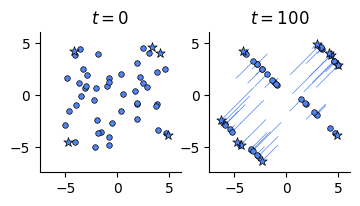

In [ ]:
np.random.seed(1)

num_steps = 100

#Initial tokens
d, n = 2, 50
z0 = np.random.rand(d,n) * 10 - 5

# Define relevant variables

A = np.eye(d)
v = np.array([1,1])  # random vector in R^d
u = v

R = np.identity(d) - 1. / (1 + np.dot(u,v)) * np.outer(u, v)
RV = 1. / (1 + np.dot(u,v)) * np.outer(u, v)
W = np.zeros((d, n))
dt_string = datetime.datetime.now().strftime("%Y-%m-%d_%H-%M-%S")
filename = dt_string + ".gif"
base_filename = dt_string

fig, z = run_hardmax_dyn_V(z0, A, R, RV, num_steps=100, tails=True)

current_datetime = datetime.datetime.now().strftime("%Y-%m-%d_%H-%M-%S")
plt.savefig(f"plots/conjV_rank1_{current_datetime}.pdf", bbox_inches="tight")

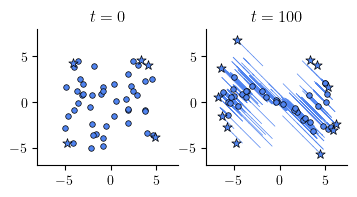

In [ ]:
v = np.array([1,1])
u = np.array([1/2,-1/2])

R = np.identity(d) - 1. / (1 + np.dot(u,v)) * np.outer(u, v)
RV = 1. / (1 + np.dot(u,v)) * np.outer(u, v)
W = np.zeros((d, n))
dt_string = datetime.datetime.now().strftime("%Y-%m-%d_%H-%M-%S")
filename = dt_string + ".gif"
base_filename = dt_string

fig, z = run_hardmax_dyn_V(z0, A, R, RV, num_steps=100, tails=True)

current_datetime = datetime.datetime.now().strftime("%Y-%m-%d_%H-%M-%S")
plt.savefig(f"plots/conjV_rank1_{current_datetime}.pdf", bbox_inches="tight")